# Data Preparation

Preparing the SMS Spam dataset. We'll load the raw data, clean it up, and split it for training.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import re
import logging
from typing import Tuple, Optional

# Config
DATA_PATH = 'SMSSpamCollection'
RANDOM_STATE = 42
TRAIN_SIZE = 0.6
VAL_SIZE = 0.2
TEST_SIZE = 0.2

# Setup logging
logging.basicConfig(level=logging.INFO, format='%(message)s')
logger = logging.getLogger(__name__)

plt.style.use('seaborn-v0_8')

In [7]:
def load_data(file_path: str) -> pd.DataFrame:
    """Load the raw SMS dataset."""
    try:
        # quoting=3 prevents parsing errors from quotes in the text itself.
        sms_df = pd.read_csv(file_path, sep='\t', names=['label', 'text'], quoting=3)
        logger.info(f"Loaded {len(sms_df)} rows.")
        return sms_df
    except FileNotFoundError:
        logger.error(f"File not found at {file_path}.")
        raise

In [8]:
def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    """Clean text and visualize class usage."""
    sms_df = df.copy()
    
    # Drop missing values
    if sms_df.isnull().sum().any():
        logger.warning("Dropping missing values...")
        sms_df.dropna(inplace=True)

    # Simple normalization: Lowercase + remove special chars
    sms_df['clean_text'] = sms_df['text'].astype(str).str.lower()
    sms_df['clean_text'] = sms_df['clean_text'].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', x))

    # Quick look at distribution
    logger.info("\nClass Distribution:")
    logger.info(sms_df['label'].value_counts(normalize=True))

    sms_df['length'] = sms_df['text'].apply(len)
    plt.figure(figsize=(10, 6))
    sns.histplot(data=sms_df, x='length', hue='label', bins=50, kde=True)
    plt.title('Message Length Distribution')
    plt.show()

    return sms_df

In [9]:
def split_and_save(df: pd.DataFrame, train_path: str = 'train.csv', val_path: str = 'validation.csv', test_path: str = 'test.csv'):
    """Split into train/val/test and save to disk."""
    
    # Standard stratified 60/20/20 split
    train_df, temp_df = train_test_split(
        df, stratify=df['label'], test_size=(VAL_SIZE + TEST_SIZE), random_state=RANDOM_STATE
    )

    val_df, test_df = train_test_split(
        temp_df, stratify=temp_df['label'], test_size=0.5, random_state=RANDOM_STATE
    )

    # Sanity checks
    assert len(train_df) + len(val_df) + len(test_df) == len(df)
    assert not set(train_df.index).intersection(set(test_df.index))

    train_df.to_csv(train_path, index=False)
    val_df.to_csv(val_path, index=False)
    test_df.to_csv(test_path, index=False)

    logger.info(f"Saved {len(train_df)} train, {len(val_df)} val, {len(test_df)} test rows.")

Loaded 5574 rows.

Class Distribution:
label
ham     0.865985
spam    0.134015
Name: proportion, dtype: float64


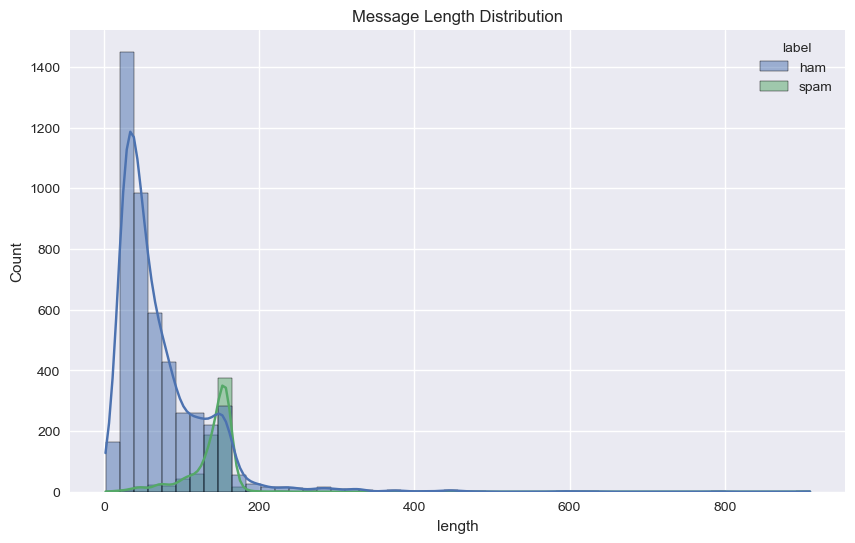

Saved 3344 train, 1115 val, 1115 test rows.


In [10]:
raw_sms_df = load_data(DATA_PATH)
clean_sms_df = preprocess_data(raw_sms_df)
split_and_save(clean_sms_df)